In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor


DATASET_PATH = './Dataset.csv'
df = pd.read_csv(DATASET_PATH)


# Part 1: Understanding the Data
df.head(), df.info(), df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CBSA                         825 non-null    int64  
 1   Core Based Statistical Area  279 non-null    object 
 2   Pollutant                    825 non-null    object 
 3   Trend Statistic              825 non-null    object 
 4   Number of Trend Sites        825 non-null    int64  
 5   1990                         435 non-null    float64
 6   1991                         435 non-null    float64
 7   1992                         435 non-null    float64
 8   1993                         435 non-null    float64
 9   1994                         435 non-null    float64
 10  1995                         435 non-null    float64
 11  1996                         435 non-null    float64
 12  1997                         435 non-null    float64
 13  1998                

(    CBSA Core Based Statistical Area Pollutant       Trend Statistic  \
 0  10420                   Akron, OH        O3               4th Max   
 1  10420                         NaN     PM2.5  Weighted Annual Mean   
 2  10420                         NaN     PM2.5       98th Percentile   
 3  10420                         NaN       SO2       99th Percentile   
 4  10500                  Albany, GA     PM2.5  Weighted Annual Mean   
 
    Number of Trend Sites    1990     1991     1992     1993     1994  ...  \
 0                      2    0.09    0.101    0.087    0.093    0.086  ...   
 1                      3     NaN      NaN      NaN      NaN      NaN  ...   
 2                      3     NaN      NaN      NaN      NaN      NaN  ...   
 3                      1  161.00  183.000  181.000  209.000  132.000  ...   
 4                      1     NaN      NaN      NaN      NaN      NaN  ...   
 
      2013   2014    2015   2016    2017    2018    2019    2020    2021   2022  
 0   0.0

In [16]:
# Part 2: Identify and Remove Zero-Variance Predictors
zero_variance_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Count of zero value colomns: {len(zero_variance_cols)}")
df.drop(columns=zero_variance_cols, inplace=True)



Count of zero value colomns: 0


In [17]:
# Part 3: Evaluate Columns with Very Few Unique Values
low_unique_cols = [col for col in df.columns if df[col].nunique() < 5]
low_unique_cols


[]

In [4]:
# Part 4: Handle Duplicate Data
duplicate_rows = df[df.duplicated()]
print("Duplicate Rows Found:")
print(duplicate_rows)

# Remove duplicate rows
df.drop_duplicates(inplace=True)
print("\nShape of dataset after removing duplicates:", df.shape)
df.head()


Duplicate Rows Found:
Empty DataFrame
Columns: [CBSA, Core Based Statistical Area, Pollutant, Trend Statistic, Number of Trend Sites, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
Index: []

[0 rows x 38 columns]

Shape of dataset after removing duplicates: (825, 38)


,CBSA,Core Based Statistical Area,Pollutant,Trend Statistic,Number of Trend Sites,1990,1991,1992,1993,1994,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
0,10420,"Akron, OH",O3,4th Max,2,0.09,0.101,0.087,0.093,0.086,...,0.059,0.06,0.065,0.06,0.066,0.068,0.062,0.063,0.067,0.07
1,10420,NaN,PM2.5,Weighted Annual Mean,3,NaN,NaN,NaN,NaN,NaN,...,9.700,9.90,10.400,8.20,7.900,7.900,8.200,7.900,8.000,7.10
2,10420,NaN,PM2.5,98th Percentile,3,NaN,NaN,NaN,NaN,NaN,...,24.000,22.00,23.000,17.00,18.000,18.000,21.000,21.000,20.000,17.00
3,10420,NaN,SO2,99th Percentile,1,161.00,183.000,181.000,209.000,132.000,...,23.000,21.00,14.000,8.00,3.000,6.000,3.000,4.000,5.000,6.00
4,10500,"Albany, GA",PM2.5,Weighted Annual Mean,1,NaN,NaN,NaN,NaN,NaN,...,10.000,10.30,9.000,8.70,9.400,8.400,9.300,9.100,10.100,8.30


In [6]:
# Part 5: Decide on the Target Column

target_col = df.columns[-1]
target_col


'2022'

In [7]:
# Part 6: Handle Missing Values
df.fillna(df.median(numeric_only=True), inplace=True)


categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    missing_percentage = df[col].isnull().mean() * 100  
    if missing_percentage > 50:
        print(f"Dropping column: {col} with {missing_percentage}% missing values")
        df.drop(columns=[col], inplace=True) 


df.isnull().sum()

Dropping column: Core Based Statistical Area with 66.18181818181819% missing values


CBSA                     0
Pollutant                0
Trend Statistic          0
Number of Trend Sites    0
1990                     0
1991                     0
1992                     0
1993                     0
1994                     0
1995                     0
1996                     0
1997                     0
1998                     0
1999                     0
2000                     0
2001                     0
2002                     0
2003                     0
2004                     0
2005                     0
2006                     0
2007                     0
2008                     0
2009                     0
2010                     0
2011                     0
2012                     0
2013                     0
2014                     0
2015                     0
2016                     0
2017                     0
2018                     0
2019                     0
2020                     0
2021                     0
2022                     0
d

In [8]:
# Part 7: Handle Categorical Data
categorical_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df.head()



,CBSA,Number of Trend Sites,1990,1991,1992,1993,1994,1995,1996,1997,...,Pollutant_PM10,Pollutant_PM2.5,Pollutant_Pb,Pollutant_SO2,Trend Statistic_4th Max,Trend Statistic_98th Percentile,Trend Statistic_99th Percentile,Trend Statistic_Annual Mean,Trend Statistic_Max 3-Month Average,Trend Statistic_Weighted Annual Mean
0,10420,2,0.09,0.101,0.087,0.093,0.086,0.092,0.091,0.087,...,False,False,False,False,True,False,False,False,False,False
1,10420,3,4.40,4.200,3.800,4.100,4.000,3.400,3.500,3.100,...,False,True,False,False,False,False,False,False,False,True
2,10420,3,4.40,4.200,3.800,4.100,4.000,3.400,3.500,3.100,...,False,True,False,False,False,True,False,False,False,False
3,10420,1,161.00,183.000,181.000,209.000,132.000,123.000,133.000,155.000,...,False,False,False,True,False,False,True,False,False,False
4,10500,1,4.40,4.200,3.800,4.100,4.000,3.400,3.500,3.100,...,False,True,False,False,False,False,False,False,False,True


In [9]:
# Part 8: Address Inconsistent Data Entry
df = df.apply(lambda col: col.map(lambda x: x.strip().lower() if isinstance(x, str) else x) if col.dtype == 'object' else col)
df.head()


,CBSA,Number of Trend Sites,1990,1991,1992,1993,1994,1995,1996,1997,...,Pollutant_PM10,Pollutant_PM2.5,Pollutant_Pb,Pollutant_SO2,Trend Statistic_4th Max,Trend Statistic_98th Percentile,Trend Statistic_99th Percentile,Trend Statistic_Annual Mean,Trend Statistic_Max 3-Month Average,Trend Statistic_Weighted Annual Mean
0,10420,2,0.09,0.101,0.087,0.093,0.086,0.092,0.091,0.087,...,False,False,False,False,True,False,False,False,False,False
1,10420,3,4.40,4.200,3.800,4.100,4.000,3.400,3.500,3.100,...,False,True,False,False,False,False,False,False,False,True
2,10420,3,4.40,4.200,3.800,4.100,4.000,3.400,3.500,3.100,...,False,True,False,False,False,True,False,False,False,False
3,10420,1,161.00,183.000,181.000,209.000,132.000,123.000,133.000,155.000,...,False,False,False,True,False,False,True,False,False,False
4,10500,1,4.40,4.200,3.800,4.100,4.000,3.400,3.500,3.100,...,False,True,False,False,False,False,False,False,False,True


In [10]:
# Part 9: Handle Dates and Times
date_cols = df.select_dtypes(include=['datetime64']).columns
for col in date_cols:
    df[col] = pd.to_datetime(df[col])
    df[f'{col}_year'] = df[col].dt.year
    df[f'{col}_month'] = df[col].dt.month
    df[f'{col}_day'] = df[col].dt.day
df.head()


,CBSA,Number of Trend Sites,1990,1991,1992,1993,1994,1995,1996,1997,...,Pollutant_PM10,Pollutant_PM2.5,Pollutant_Pb,Pollutant_SO2,Trend Statistic_4th Max,Trend Statistic_98th Percentile,Trend Statistic_99th Percentile,Trend Statistic_Annual Mean,Trend Statistic_Max 3-Month Average,Trend Statistic_Weighted Annual Mean
0,10420,2,0.09,0.101,0.087,0.093,0.086,0.092,0.091,0.087,...,False,False,False,False,True,False,False,False,False,False
1,10420,3,4.40,4.200,3.800,4.100,4.000,3.400,3.500,3.100,...,False,True,False,False,False,False,False,False,False,True
2,10420,3,4.40,4.200,3.800,4.100,4.000,3.400,3.500,3.100,...,False,True,False,False,False,True,False,False,False,False
3,10420,1,161.00,183.000,181.000,209.000,132.000,123.000,133.000,155.000,...,False,False,False,True,False,False,True,False,False,False
4,10500,1,4.40,4.200,3.800,4.100,4.000,3.400,3.500,3.100,...,False,True,False,False,False,False,False,False,False,True


In [11]:
# Part 10: Split the Data into Training and Testing Sets
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
(X_train.shape, X_test.shape)


((660, 46), (165, 46))

In [12]:
# Part 11: Scaling and Normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [13]:
# Part 12: Data Modeling
# if df[target_col].dtype == 'float64' or df[target_col].dtype == 'int64':
#     model = LinearRegression()
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     error = mean_squared_error(y_test, y_pred)
#     error
# else:
#     model = DecisionTreeClassifier()
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     acc = accuracy_score(y_test, y_pred)
#     acc

# Part 12: Data Modeling

# Split the dataset into features (X) and target (y)
X = df.drop(columns=[target_col])  # Assuming target_col is your target column
y = df[target_col]

# Initialize models

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor



if y.dtype in ['float64', 'int64']:  
    linear_reg_model = LinearRegression()
    linear_reg_model.fit(X_train, y_train)
    y_pred_reg = linear_reg_model.predict(X_test)
    reg_error = mean_squared_error(y_test, y_pred_reg)
    print("Linear Regression MSE:", reg_error)
else:
    reg_error = None  


if y.dtype in ['float64', 'int64']: 
    decision_tree_model = DecisionTreeRegressor()  
    decision_tree_model.fit(X_train, y_train)
    y_pred_tree = decision_tree_model.predict(X_test)
    tree_error = mean_squared_error(y_test, y_pred_tree)
    print("Decision Tree Regressor MSE:", tree_error)
else:  
    decision_tree_model = DecisionTreeClassifier() 
    decision_tree_model.fit(X_train, y_train)
    y_pred_tree = decision_tree_model.predict(X_test)
    tree_acc = accuracy_score(y_test, y_pred_tree)
    print("Decision Tree Accuracy:", tree_acc)


Linear Regression MSE: 27.651161445112827
Decision Tree Regressor MSE: 59.30333805454545


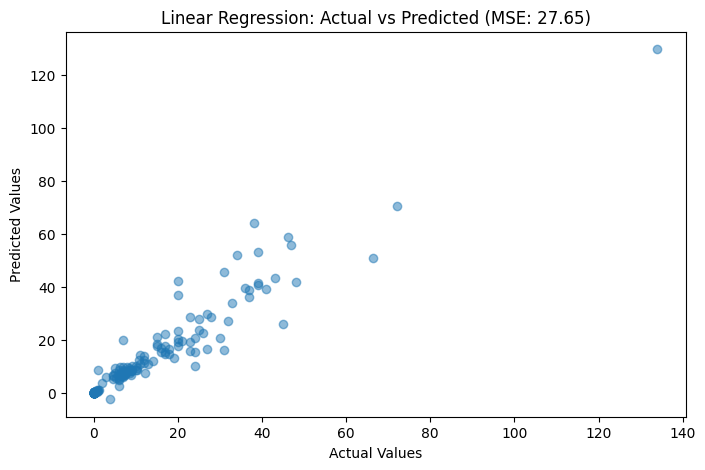

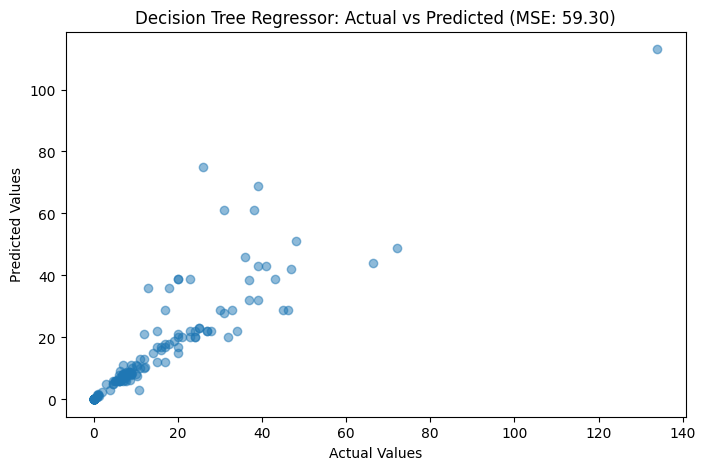

In [14]:
# Part 13: Presenting the Results
if reg_error is not None:
    plt.figure(figsize=(8, 5))
    plt.scatter(y_test, y_pred_reg, alpha=0.5)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"Linear Regression: Actual vs Predicted (MSE: {reg_error:.2f})")
    plt.show()


if tree_error is not None: 
    plt.figure(figsize=(8, 5))
    plt.scatter(y_test, y_pred_tree, alpha=0.5)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"Decision Tree Regressor: Actual vs Predicted (MSE: {tree_error:.2f})")
    plt.show()

